In [7]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [8]:
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    
    # 군집별 중심 위치: K-Means, Mean Shift 등
    if iscenter:
        centers = clusterobj.cluster_centers_
    
    # Cluster 값 종류
    unique_labels = np.unique(dataframe[label_name].values)
    
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        # 군집별 데이터 프레임
        label_cluster = dataframe[dataframe[label_name]==label]
        
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else:
            cluster_legend = 'Cluster '+str(label)
        
        # 각 군집 시각화
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,
                    edgecolor='k', marker=markers[label], label=cluster_legend)
        
        # 군집별 중심 위치 시각화
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
            
    if isNoise:
        legend_loc='upper center'
    else: 
        legend_loc='upper right'
    
    plt.legend(loc=legend_loc)
    plt.show()

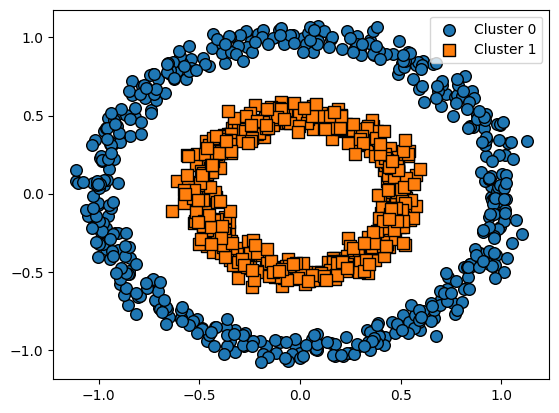

In [9]:
from sklearn.datasets import make_circles


X, y = make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)

cluster_df = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
cluster_df['target'] = y

# 가상데이터 시각화
visualize_cluster_plot(None, cluster_df, 'target', iscenter=False)

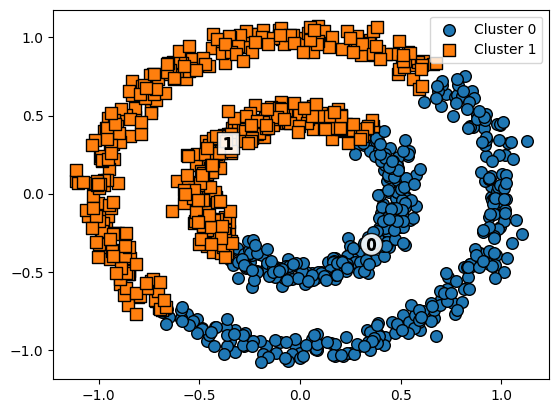

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

cluster_df["kmeans_cluster"] = kmeans_labels

visualize_cluster_plot(kmeans, cluster_df, 'kmeans_cluster', iscenter=True)

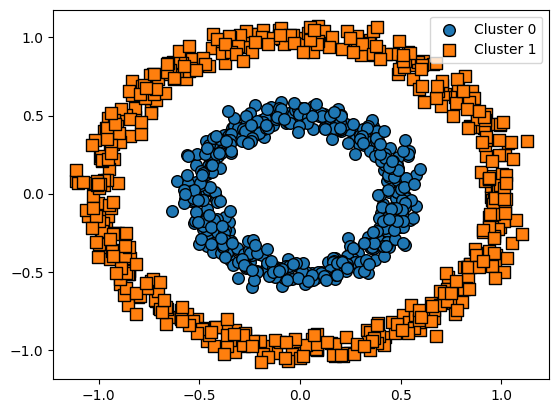

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=10, metric="euclidean")
dbscan_labels = dbscan.fit_predict(X)

cluster_df["dbscan_cluster"] = dbscan_labels

visualize_cluster_plot(dbscan, cluster_df, 'dbscan_cluster', iscenter=False)

#### 🔥 핵심 흐름 (진짜 중요)
1. k-distance 계산
2. 정렬
3. elbow 찾기
4. eps 설정
5. DBSCAN 실행

```
🧠 핵심 포인트
✔ eps = 0.2
너무 작으면 쪼개짐
너무 크면 합쳐짐
✔ min_samples = 5
군집 최소 조건
```

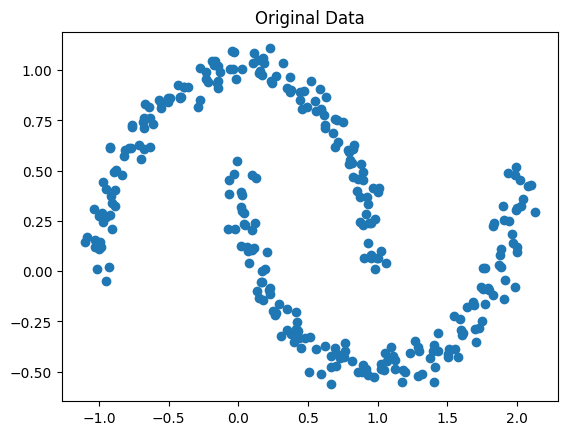

In [13]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.show()

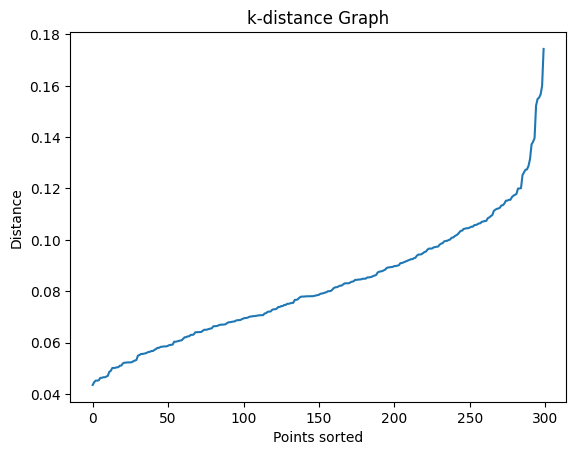

In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# min_samples와 동일하게 설정
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

distances, _ = neighbors_fit.kneighbors(X)

# k번째 거리만 추출
k_distances = distances[:, -1]

# 정렬
k_distances = np.sort(k_distances)

# 그래프
plt.plot(k_distances)
plt.title("k-distance Graph")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()

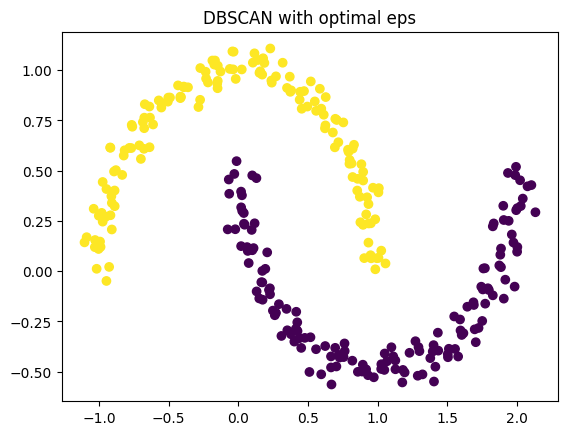

In [22]:
from sklearn.cluster import DBSCAN

# 위에서 찾은 eps 사용
model = DBSCAN(eps=0.15, min_samples=5)

labels = model.fit_predict(X)

# 시각화
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN with optimal eps")
plt.show()

📊 핵심 차이
| 항목     | DBSCAN | K-Means |
| ------ | ------ | ------- |
| 기준     | 밀도     | 거리 중심   |
| 군집 모양  | 자유로움   | 원형      |
| k 필요   | ❌      | ✔       |
| 노이즈 처리 | ✔ (-1) | ❌       |

```
🧠 핵심 직관
K-Means → "중심 기준으로 나눔"
DBSCAN → "붙어 있는 애들끼리 묶음"
```

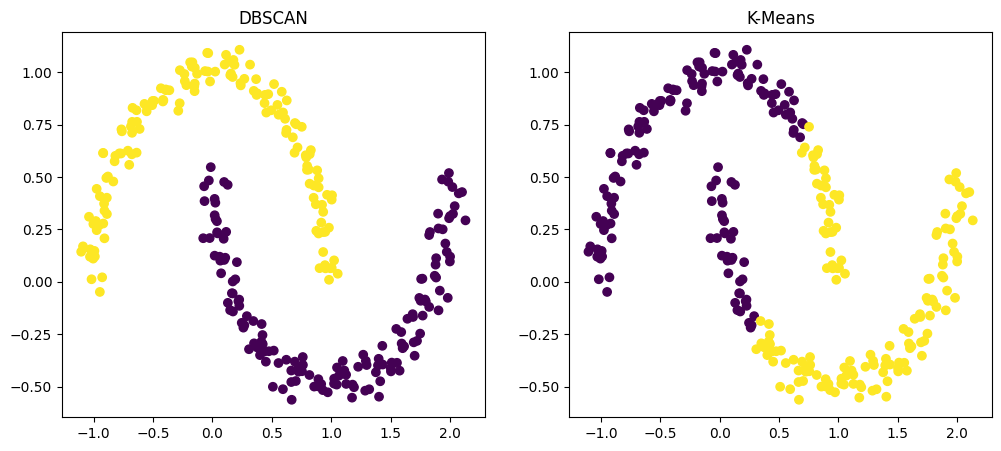

In [1]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt

# 1. 데이터 생성
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X)

# 3. K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(X)

# 4. 시각화
plt.figure(figsize=(12, 5))

# DBSCAN 결과
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=db_labels)
plt.title("DBSCAN")

# K-Means 결과
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=km_labels)
plt.title("K-Means")

plt.show()